# 04 · A²/A³ – Features anpassen, Hyperparameter justieren

Räumliches HGB-Tuning, inkrementelle Feature-Ablation und Modellartefakt.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## A² – Adapting Features

Die zweite A-Iteration fragt nicht „welches Modell?“, sondern „welche Information hilft dem gewählten Modell wirklich?“. MietCheck ergänzt Merkmale inkrementell:

1. **Kategorien-Baseline:** nur Gebäudealter und Wohnungsgröße,
2. **+ Lage:** ETRS89-LAEA-Koordinaten,
3. **+ Kontext:** Bevölkerung, Haushalt, Eigentum, Leerstand und Wohnungsbestand,
4. **+ Qualitätsflags:** amtliche Unsicherheitskennzeichen.

Die Ablation fügt Gruppen schrittweise hinzu und prüft jede Stufe auf denselben Raum-Folds. So wird nicht nur eine Feature Importance gezeigt, sondern der messbare Zusatznutzen ganzer Informationsgruppen.

## A³ – Adjusting Hyperparameters

HGB besitzt Regler für Lernrate, Baumkomplexität, Mindestbeobachtungen je Blatt, Regularisierung und Iterationszahl. Acht begründete Konfigurationen werden innerhalb der Entwicklungsdaten verglichen. Das finale Testset bleibt während dieser Suche vollständig versiegelt.

## Datensperre

Vor dem Tuning wurden 663 Raumblöcke in Entwicklung (70 %), Kalibrierung (15 %) und Test (15 %) geteilt. Nur Entwicklungsblöcke dürfen Parameter und Features beeinflussen. SHA-256-Fingerabdrücke machen Partitionsdrift sichtbar.

In [2]:
tuning = load_json("reports/hgb_tuning.json")
partition = pd.DataFrame(tuning["partition"]).T
display(partition)
assert partition["group_sha256"].nunique() == 3
assert partition["blocks"].sum() == 663
print("✓ Drei disjunkt versionierte Partitionsfingerabdrücke")

,rows,blocks,group_sha256
calibration,263789,99,d1fe0f764572bbd052c31814836042dadbfe8edf49b599...
test,276458,99,7da06f24d2392e949706323e217bda2003271bc5c6493b...
development,1518322,465,efab4dce9c5513307d85e5c8a7c22485c702a77208cbb5...


✓ Drei disjunkt versionierte Partitionsfingerabdrücke


Kandidat,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mean_mae,std_mae,worst_fold_mae,mean_r2,mean_training_seconds
6,0.060000,300,127,100,5.000000,1.270100,0.031800,1.298700,0.364500,26.155000
7,0.080000,250,127,250,10.000000,1.270800,0.032200,1.302100,0.365400,20.531500
8,0.100000,200,63,250,10.000000,1.272100,0.031800,1.306400,0.364100,12.359700
5,0.080000,250,63,100,5.000000,1.272100,0.034800,1.307400,0.364200,14.930400
3,0.060000,300,63,100,1.000000,1.273600,0.036600,1.311700,0.363000,18.800600
4,0.080000,250,63,50,0.000000,1.275700,0.034200,1.312400,0.360100,15.277000
2,0.060000,300,31,250,5.000000,1.286000,0.039600,1.328600,0.354000,14.807700
1,0.040000,350,31,100,1.000000,1.291100,0.042000,1.338800,0.349300,17.582000


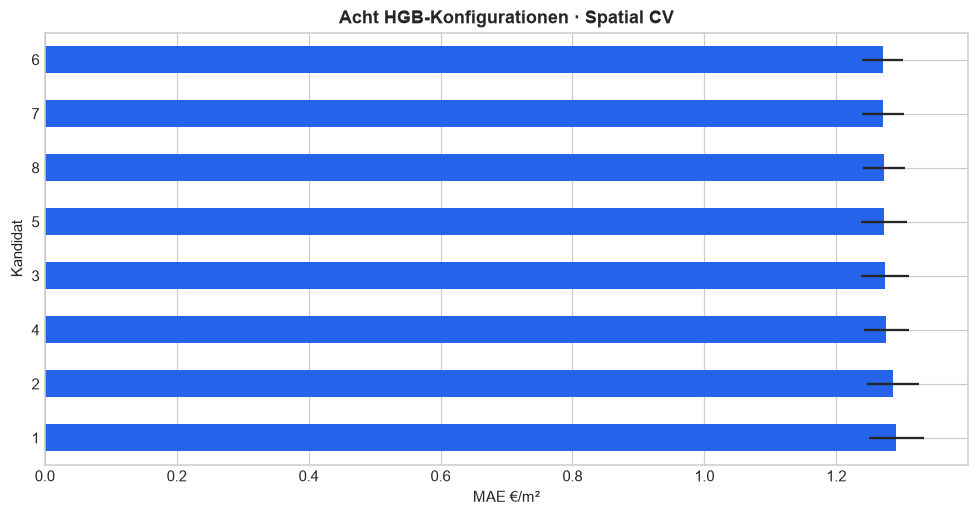

Gewählte Parameter: {'learning_rate': 0.06, 'max_iter': 300, 'max_leaf_nodes': 127, 'min_samples_leaf': 100, 'l2_regularization': 5.0}


In [3]:
candidate_rows = []
for item in tuning["candidates"]:
    candidate_rows.append({"Kandidat": item["candidate"], **item["parameters"], **item["summary"]})
candidates = pd.DataFrame(candidate_rows).sort_values("mean_mae")
display(candidates.round(4).style.hide(axis="index"))

ax = candidates.sort_values("mean_mae", ascending=False).plot.barh(
    x="Kandidat", y="mean_mae", xerr="std_mae", color=COLORS["blue"], legend=False
)
ax.set(title="Acht HGB-Konfigurationen · Spatial CV", xlabel="MAE €/m²", ylabel="Kandidat")
plt.tight_layout(); plt.show()
print("Gewählte Parameter:", tuning["selected_parameters"])

feature_set,mean_mae,improvement_vs_categories,improvement_vs_previous,features,mean_r2
categories_only,1.645200,0.000000,nan,2,0.044200
location,1.350600,0.179100,0.179100,4,0.290600
location_plus_numeric_context,1.315400,0.200500,0.026100,10,0.320700
all_context_and_quality_flags,1.294000,0.213500,0.016200,15,0.335800


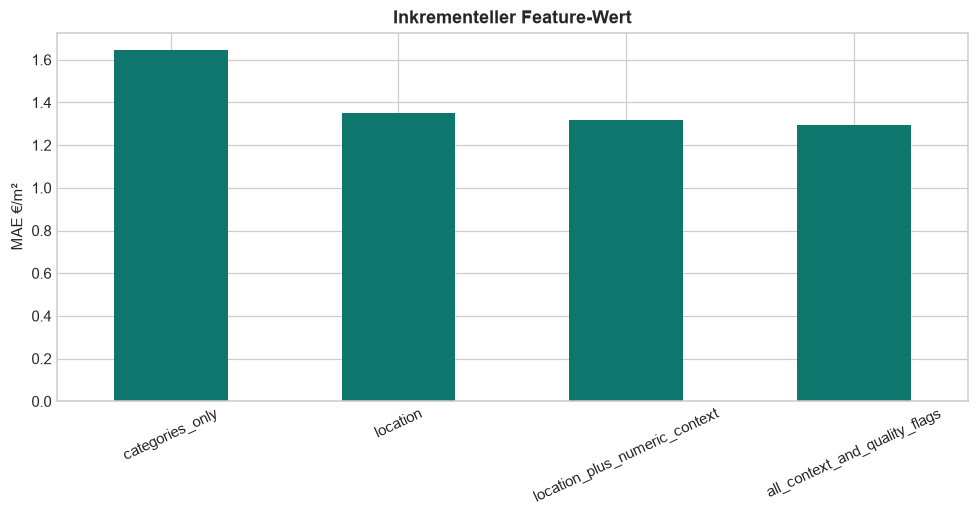

In [4]:
ablation = load_json("reports/feature_ablation.json")
rows = []
for item in ablation["incremental_comparison"]:
    detail = ablation["feature_sets"][item["feature_set"]]
    rows.append({**item, "features": len(detail["features"]),
                 "mean_r2": detail["summary"]["mean_r2"]})
abl = pd.DataFrame(rows)
display(abl.round(4).style.hide(axis="index"))

ax = abl.plot.bar(x="feature_set", y="mean_mae", color=COLORS["teal"], legend=False)
ax.set(title="Inkrementeller Feature-Wert", ylabel="MAE €/m²", xlabel="")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

In [5]:
meta = load_json("models/zensus_hgb_meta.json")
artifact = ROOT / "models/zensus_hgb.joblib"
artifact_summary = pd.DataFrame([
    ("Modell", meta["model_name"]),
    ("Features", len(meta["feature_order"])),
    ("Trainingszeilen", meta["training_rows"]),
    ("Kalibrierungszeilen", meta["calibration_rows"]),
    ("Testzeilen", meta["test_rows"]),
    ("Artefaktgröße MB", artifact.stat().st_size / 1e6),
    ("scikit-learn", meta["sklearn_version"]),
], columns=["Eigenschaft", "Wert"])
display(artifact_summary)
assert artifact.exists() and artifact.stat().st_size > 100_000

,Eigenschaft,Wert
0,Modell,MietCheck Zensus stock-rent HGB
1,Features,15
2,Trainingszeilen,1518322
3,Kalibrierungszeilen,263789
4,Testzeilen,276458
5,Artefaktgröße MB,2.049564
6,scikit-learn,1.8.0


## Ergebnis und Modellartefakt

Kandidat 6 (`learning_rate=.06`, 127 Blätter, 100 Mindestbeobachtungen je Blatt, L2=5) besitzt sowohl den niedrigsten mittleren als auch den niedrigsten schlechtesten Fold-MAE. Die Entscheidung belohnt damit nicht nur den besten Durchschnitt, sondern auch Stabilität.

Standort bringt in A² den größten Effekt. Numerischer Kontext und Qualitätsflags verbessern jedoch **alle** Folds und bleiben deshalb im 15-Feature-Modell. Modell, Feature-Reihenfolge, Softwareversion, Splits und Parameter werden gemeinsam versioniert; die App muss exakt dieses Artefakt laden und trainiert nichts stillschweigend neu.

**Übergabe an C:** Erst nach Abschluss aller A-Entscheidungen wird das gesperrte Testset einmalig geöffnet.

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.